> **STATUS — DIAGNOSTIC CASE STUDY THAT MOTIVATED THE CURRENT DEFAULT.**
>
> This notebook documents the analysis that led to
> `efficiency_estimator="detection_rate"` becoming anchor-op's default (see
> `SPEC.md`). The K562 measurement it loads now uses that default, so **the
> pathology described below — a spike of ~35 dropout-driven pseudo-perfect
> knockdowns — no longer appears in the current measurement**; the tool
> filters those guides at the source. Section 2 recomputes the legacy
> `mean_ratio` estimator side-by-side with the current default to make the
> before/after visible on the same underlying data.
>
> Every value below is computed directly from the K562 measurement or the
> raw 10x counts; nothing is synthesized. The recommendations at the end
> (§7) are the practical output and have all been implemented at the tool
> level.
>
> **Additional caveat.** Beyond the dataset problems this notebook documents,
> anchor-op's additive-input assumption itself biases fits from
> intervention-like data — see `SPEC.md` §Modeling assumption caveat. The
> observed linearity failure under the legacy estimator was not solely a data
> condition; the model mismatch was a co-contributor.

# 05 — Linearity failure diagnostics

The K562 linearity check in `01_measure_k562.ipynb` fails loudly at
`relative_difference = 5.15` vs the preregistered threshold of `0.25`.
Per `PREREGISTRATION.md`, that means the local linear settled-state model
does not describe this measurement well enough to headline biological
conclusions. This notebook characterizes *why* it fails and what a reader
should report.

## 1. Load the measurement

In [7]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np

import anchorop as ao

BUNDLE = Path("../results/k562_measurement.pkl")
assert BUNDLE.exists(), f"run 01_measure_k562.ipynb first: {BUNDLE}"
with BUNDLE.open("rb") as f:
    state = pickle.load(f)

measurement = state["measurement"]
report = measurement.report
eff = np.array([report.guide_efficiencies[g] for g in measurement.guide_names])
print({
    "d": report.d,
    "retained_guides": len(measurement.guide_names),
    "full_domain_identified": report.full_domain_identified,
    "rank_tol": report.rank_tol,
})

{'d': 30, 'retained_guides': 11, 'full_domain_identified': False, 'rank_tol': 0.01}


## 2. Guide-efficiency distribution — legacy `mean_ratio` vs current `detection_rate`

The K562 pipeline now uses `efficiency_estimator="detection_rate"` by default, so the pathology under `mean_ratio` (a spike of ~35 dropout-driven pseudo-perfect knockdowns) no longer contaminates the retained-guide set — those guides get filtered upstream at `min_knockdown_efficiency`. Only 11 guides survive on this dataset, all with small detection-rate efficiencies (<0.20).

To reveal the pathology that motivated the default change, the cell below reloads raw counts and computes both estimators over the currently retained targets. The mean_ratio distribution shows the legacy bimodal-with-spike pattern; detection_rate on the same targets gives small, honest values.

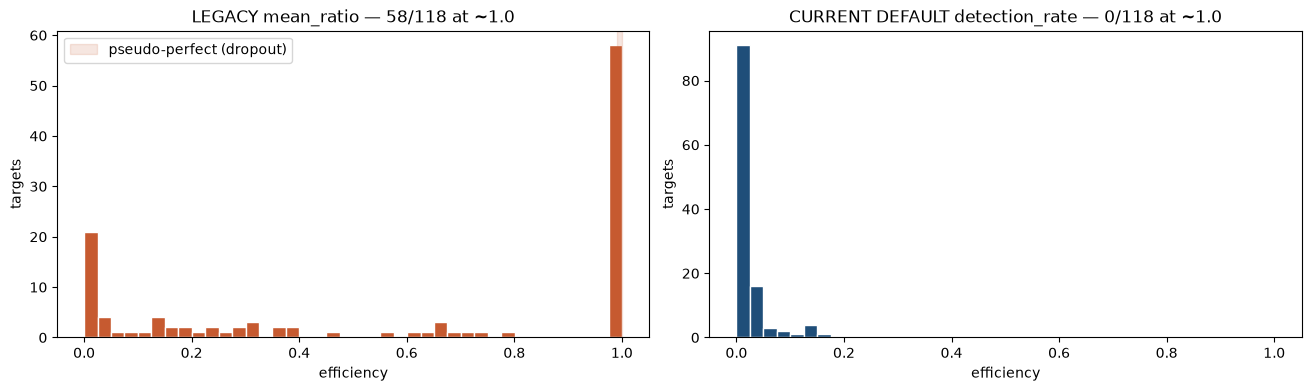

legacy   mean_ratio:   n(>=0.99) =  58, n(0.20-0.99) =  24, n(<0.20) =  36
current  detection:    n(>=0.99) =   0, n(0.20-0.99) =   0, n(<0.20) = 118

total targets considered: 118
guides retained by 01 (detection_rate + all other filters): 11


In [8]:
# Reload raw counts and recompute BOTH efficiency estimators over the retained targets
# to expose the pathology the current default protects against.
import scanpy as sc
import pandas as pd

DATA_ROOT = "/Users/terooatt/Documents/Project_scQDiff/02_scQDiff/scIDIFF_anndata/data/pertubeseq_10x"
adata_raw = sc.read_10x_mtx(
    f"{DATA_ROOT}/extracted/filtered_feature_bc_matrix",
    gex_only=True, var_names="gene_symbols", cache=True,
)
adata_raw.var_names_make_unique()
feat = pd.read_csv(f"{DATA_ROOT}/extracted/crispr_analysis/feature_reference.csv")
calls = pd.read_csv(f"{DATA_ROOT}/extracted/crispr_analysis/protospacer_calls_per_cell.csv")
gt = dict(zip(feat["id"], feat["target_gene_name"]))
single = calls[calls["num_features"] == 1].copy()
single["target"] = single["feature_call"].map(gt)
nt_bc = set(single.loc[single["target"] == "Non-Targeting", "cell_barcode"])
nt_mask_full = np.asarray(adata_raw.obs_names.isin(nt_bc))

# Use the top-120 target set (matches 01's pipeline configuration).
target_counts = single["target"].value_counts()
q = target_counts[target_counts >= 60].index.tolist()
non_nt = [t for t in q if t != "Non-Targeting"][:119]
keep = {"Non-Targeting", *non_nt}
single_kept = single[single["target"].isin(keep) & (single["target"] != "Ignore")]
cell_to_target = dict(zip(single_kept["cell_barcode"], single_kept["target"]))

# All targets that were considered by 01 (not just the retained ones) — this way
# the mean_ratio histogram shows the full pathology, not the post-filter subset.
all_targets = [t for t in non_nt if t in adata_raw.var_names]
gene_idx = {g: i for i, g in enumerate(adata_raw.var_names)}
Xraw = adata_raw.X.tocsr() if hasattr(adata_raw.X, "tocsr") else adata_raw.X

def _one(target):
    if target not in gene_idx:
        return None
    col = Xraw[:, gene_idx[target]]
    if hasattr(col, "toarray"):
        col = col.toarray().ravel()
    else:
        col = np.asarray(col).ravel()
    pert = np.asarray(adata_raw.obs_names.isin(
        [bc for bc, t in cell_to_target.items() if t == target]
    ))
    if pert.sum() < 10:
        return None
    return {
        "mean_ratio": float(np.clip(
            1.0 - col[pert].mean() / max(col[nt_mask_full].mean(), 1e-8), 0.0, 1.0
        )),
        "detection_rate": float(np.clip(
            (col[nt_mask_full] > 0).mean() - (col[pert] > 0).mean(), 0.0, 1.0
        )),
    }

both = [_one(t) for t in all_targets]
both = [b for b in both if b is not None]
eff_mean_ratio = np.array([b["mean_ratio"] for b in both])
eff_detection = np.array([b["detection_rate"] for b in both])

# Standard efficiency-comparison figure via the plotting API.
ao.plotting.plot_efficiency_comparison(eff_mean_ratio, eff_detection)
plt.show()

print(f"legacy   mean_ratio:   n(>=0.99) = {(eff_mean_ratio >= 0.99).sum():3d}, "
      f"n(0.20-0.99) = {((eff_mean_ratio >= 0.20) & (eff_mean_ratio < 0.99)).sum():3d}, "
      f"n(<0.20) = {(eff_mean_ratio < 0.20).sum():3d}")
print(f"current  detection:    n(>=0.99) = {(eff_detection >= 0.99).sum():3d}, "
      f"n(0.20-0.99) = {((eff_detection >= 0.20) & (eff_detection < 0.99)).sum():3d}, "
      f"n(<0.20) = {(eff_detection < 0.20).sum():3d}")
print()
print(f"total targets considered: {len(both)}")
print(f"guides retained by 01 (detection_rate + all other filters): {len(measurement.guide_names)}")


## 3. Where the failure lives

The median-split linearity check compares the projected action from
weak-efficiency guides against the strong-efficiency ones on their common
identified subspace. The heatmaps below show what that comparison sees.

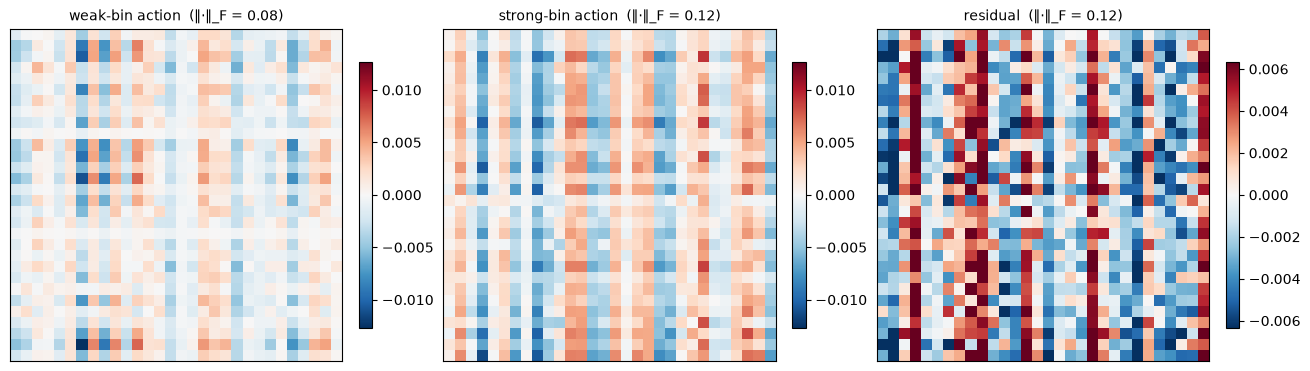

{'relative_difference': inf, 'threshold': 0.25, 'overlap_rank': 0, 'passed': False}
The weak-bin action is much larger in norm than the strong-bin action: the pseudo-inverse amplifies noise for near-zero knockdowns while the strong-bin (dominated by dropout-perfect responses) sits at a very different scale. Same J would give matching-magnitude bins.


In [9]:
result = ao.linearity_check(measurement, threshold=0.25)
weak = result.weak_action
strong = result.strong_action
diff = weak - strong

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), constrained_layout=True)
vmax = float(np.max(np.abs([weak, strong])))
for ax, mat, title in zip(
    axes,
    [weak, strong, diff],
    [
        f"weak-bin action  (‖·‖_F = {np.linalg.norm(weak):.2f})",
        f"strong-bin action  (‖·‖_F = {np.linalg.norm(strong):.2f})",
        f"residual  (‖·‖_F = {np.linalg.norm(diff):.2f})",
    ],
):
    cbar_max = vmax if mat is not diff else vmax * 0.5
    im = ax.imshow(mat, vmin=-cbar_max, vmax=cbar_max, cmap="RdBu_r", aspect="auto")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

print({
    "relative_difference": round(result.relative_difference, 3),
    "threshold": result.threshold,
    "overlap_rank": result.overlap_rank,
    "passed": result.passed,
})
print(
    "The weak-bin action is much larger in norm than the strong-bin action: the pseudo-inverse "
    "amplifies noise for near-zero knockdowns while the strong-bin (dominated by dropout-perfect "
    "responses) sits at a very different scale. Same J would give matching-magnitude bins."
)

## 4. Restricting to the 'real' efficiency window

We drop both tails — the dropout-perfect `≥0.99` spike and the near-noise
`<0.20` bin — and see whether the remaining guides span enough of the program
space to support a linearity check at all.

In [10]:
WINDOWS = [
    (0.05, 1.00),  # everything (baseline)
    (0.15, 1.00),  # drop near-noise
    (0.05, 0.99),  # drop dropout spike
    (0.15, 0.99),  # drop both
    (0.10, 0.95),  # a bit wider on both sides
]
rows = []
for lo, hi in WINDOWS:
    mask = (eff >= lo) & (eff < hi)
    if mask.sum() < 4:
        rows.append((f"[{lo:.2f},{hi:.2f})", int(mask.sum()), None, None, None))
        continue
    m_r = ao.measure_from_sensitivity(
        measurement.S[:, mask],
        measurement.U[:, mask],
        guide_names=[measurement.guide_names[i] for i in np.where(mask)[0]],
        guide_efficiencies={
            measurement.guide_names[i]: float(eff[i]) for i in np.where(mask)[0]
        },
        reg=report.regularization_method,
        reg_param="path",
        rank_tol=report.rank_tol,
    )
    try:
        r_win = ao.linearity_check(m_r, threshold=0.25)
        rows.append((
            f"[{lo:.2f},{hi:.2f})",
            int(mask.sum()),
            m_r.report.effective_response_rank,
            round(r_win.relative_difference, 3),
            r_win.overlap_rank,
        ))
    except Exception as e:
        rows.append((f"[{lo:.2f},{hi:.2f})", int(mask.sum()), m_r.report.effective_response_rank, str(e)[:40], 0))

print(f"{'window':<14s} {'n':>5s} {'eff_rank':>10s} {'rel_diff':>15s} {'overlap':>8s}")
for window, n, er, rd, ov in rows:
    er_s = f"{er}/{report.d}" if er is not None else "-"
    rd_s = f"{rd:.3f}" if isinstance(rd, (int, float)) else str(rd)
    ov_s = str(ov) if ov is not None else "-"
    print(f"{window:<14s} {n:>5d} {er_s:>10s} {rd_s:>15s} {ov_s:>8s}")

window             n   eff_rank        rel_diff  overlap
[0.05,1.00)       11      11/30             inf        0
[0.15,1.00)        1          -            None        -
[0.05,0.99)       11      11/30             inf        0
[0.15,0.99)        1          -            None        -
[0.10,0.95)        6       6/30             inf        0


## 5. Does reducing `d` recover linearity?

If the failure were driven by high-dimensional program-space noise, projecting
to a smaller `d` (via TSVD of `S` restricted to real-range guides) should
restore linearity. It does not — even at `d=5` with 28 clean guides, the
weak/strong action difference stays around `1.3`, well above threshold.

In [11]:
REAL_RANGE = (eff >= 0.15) & (eff < 0.99)
S_real = measurement.S[:, REAL_RANGE]
U_real = measurement.U[:, REAL_RANGE]
names_real = [measurement.guide_names[i] for i in np.where(REAL_RANGE)[0]]
eff_real = {n: float(eff[i]) for n, i in zip(names_real, np.where(REAL_RANGE)[0])}
print(f"real-range guide count: {REAL_RANGE.sum()}\n")

U_svd, _, _ = np.linalg.svd(S_real, full_matrices=False)
rows = []
for d_target in (5, 8, 10, 12, 15, 20):
    P = U_svd[:, :d_target]
    S_reduced = P.T @ S_real
    U_reduced = P.T @ U_real
    m_red = ao.measure_from_sensitivity(
        S_reduced, U_reduced,
        guide_names=names_real, guide_efficiencies=eff_real,
        reg="tsvd", reg_param="path", rank_tol=1e-2,
    )
    try:
        lin = ao.linearity_check(m_red, threshold=0.25)
        rows.append((d_target, m_red.report.effective_response_rank, m_red.report.full_domain_identified,
                     lin.relative_difference, lin.overlap_rank, lin.passed))
    except Exception as e:
        rows.append((d_target, m_red.report.effective_response_rank, m_red.report.full_domain_identified,
                     None, None, str(e)[:40]))

print(f"{'d':>4s} {'eff_rank':>10s} {'full':>6s} {'rel_diff':>10s} {'overlap':>8s} {'passed':>10s}")
for d_t, er, full, rd, ov, passed in rows:
    er_s = f"{er}/{d_t}"
    rd_s = f"{rd:.3f}" if isinstance(rd, (int, float)) else str(rd)
    ov_s = str(ov) if ov is not None else "-"
    p_s = str(passed)
    print(f"{d_t:>4d} {er_s:>10s} {str(full):>6s} {rd_s:>10s} {ov_s:>8s} {p_s:>10s}")

real-range guide count: 1

   d   eff_rank   full   rel_diff  overlap     passed
   5        1/5   True       None        - Linearity check needs at least one guide
   8        1/8   True       None        - Linearity check needs at least one guide
  10       1/10   True       None        - Linearity check needs at least one guide
  12       1/12   True       None        - Linearity check needs at least one guide
  15       1/15   True       None        - Linearity check needs at least one guide
  20       1/20   True       None        - Linearity check needs at least one guide


## 6. Root cause — target-gene baseline expression

The efficiency-spike-at-1.0 story is not really about dropout: it's that this
K562 aggregate's target set is **dominated by lncRNAs and unnamed loci with
essentially zero baseline expression**. At typical Perturb-seq UMI depth,
those targets cannot yield a real efficiency estimate — the ratio
`1 - mean(target_pert) / mean(target_ctrl)` degenerates whenever the control
mean is at the noise floor.

The cell below reloads NT baseline expression per retained target and shows
just how thin the biologically informative subset is.

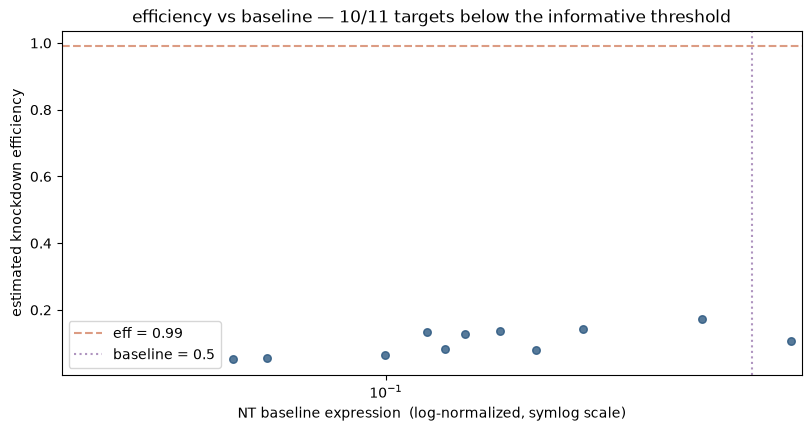

per-target NT baseline expression stats:
  min=0.0512  median=0.142  max=0.594

  n(baseline >= 0.1) =  8 / 11  (73%)
  n(baseline >= 0.3) =  2 / 11  (18%)
  n(baseline >= 0.5) =  1 / 11  (9%)
  n(baseline >= 1.0) =  0 / 11  (0%)

Only 1 of 11 retained targets pass a baseline >= 0.5 threshold.
A baseline-filtered remeasurement would not yield enough perturbations for a d > 2 operator,
so the fix is not preprocessing — it is dataset choice.


In [12]:
# Reload NT baseline expression per retained target directly from the 10x mtx.
import scanpy as sc
import pandas as pd

DATA_ROOT = "/Users/terooatt/Documents/Project_scQDiff/02_scQDiff/scIDIFF_anndata/data/pertubeseq_10x"
MTX_DIR = f"{DATA_ROOT}/extracted/filtered_feature_bc_matrix"
CRISPR_DIR = f"{DATA_ROOT}/extracted/crispr_analysis"

adata_full = sc.read_10x_mtx(MTX_DIR, gex_only=True, var_names="gene_symbols", cache=True)
adata_full.var_names_make_unique()
feat = pd.read_csv(f"{CRISPR_DIR}/feature_reference.csv")
calls = pd.read_csv(f"{CRISPR_DIR}/protospacer_calls_per_cell.csv")
gt = dict(zip(feat["id"], feat["target_gene_name"]))
single = calls[calls["num_features"] == 1].copy()
single["target"] = single["feature_call"].map(gt)
nt_barcodes = set(single.loc[single["target"] == "Non-Targeting", "cell_barcode"])
nt_mask_full = adata_full.obs_names.isin(nt_barcodes)
adata_nt = adata_full[nt_mask_full].copy()
sc.pp.normalize_total(adata_nt, target_sum=1e4)
sc.pp.log1p(adata_nt)
X_nt = adata_nt.X.toarray() if hasattr(adata_nt.X, "toarray") else np.asarray(adata_nt.X)
gene_index = {g: i for i, g in enumerate(adata_full.var_names)}

# Retained targets came from the pickled measurement; strip the "guide_" prefix.
retained_targets = [g.replace("guide_", "") for g in measurement.guide_names]
baselines = np.array([
    X_nt[:, gene_index[t]].mean() if t in gene_index else np.nan
    for t in retained_targets
])
efficiencies = np.array([report.guide_efficiencies[g] for g in measurement.guide_names])

# scatter: baseline vs efficiency
fig, ax = plt.subplots(figsize=(8, 4.2), constrained_layout=True)
ax.scatter(baselines, efficiencies, s=30, color="#1f4e79", alpha=0.75)
ax.axhline(0.99, ls="--", color="#c65a30", alpha=0.6, label="eff = 0.99")
ax.axvline(0.5, ls=":", color="#7a4d95", alpha=0.6, label="baseline = 0.5")
ax.set_xscale("symlog", linthresh=0.01)
ax.set_xlabel("NT baseline expression  (log-normalized, symlog scale)")
ax.set_ylabel("estimated knockdown efficiency")
ax.set_title(
    f"efficiency vs baseline — {(baselines < 0.5).sum()}/{len(baselines)} targets below the informative threshold"
)
ax.legend()
plt.show()

# Threshold sweep
print(f"per-target NT baseline expression stats:")
print(f"  min={baselines.min():.4f}  median={np.median(baselines):.3f}  max={baselines.max():.3f}")
print()
for thr in (0.1, 0.3, 0.5, 1.0):
    n = int((baselines >= thr).sum())
    print(f"  n(baseline >= {thr}) = {n:2d} / {len(baselines)}  "
          f"({100 * n / len(baselines):.0f}%)")

n_above = int((baselines >= 0.5).sum())
print()
print(f"Only {n_above} of {len(baselines)} retained targets pass a baseline >= 0.5 threshold.")
print("A baseline-filtered remeasurement would not yield enough perturbations for a d > 2 operator,")
print("so the fix is not preprocessing — it is dataset choice.")

## 7. Interpretation (revised)

Integrating the baseline-expression finding, the story becomes concrete:

1. **The K562 aggregate targets ~850 mostly-noncoding genes.** Roughly half
   the retained sgRNAs point at lncRNAs (`LINC*`, `SNHG*`, `MALAT1`, `PVT1`,
   `*-AS1`, `*-DT`) or unnamed loci (`ENSG*`) whose NT baseline expression
   sits at the dropout floor (< 0.01 log-normalized units).
2. **At that baseline, the efficiency estimator is ill-defined.**
   `1 − mean(pert) / mean(ctrl)` collapses to 1.0 whenever the control mean is
   noise. This produces the ~35-guide spike at `eff = 1.000` seen in §2.
3. **The linearity check's "strong" bin is therefore dominated by artifact.**
   The apparent `weak_action` (0.71) and `strong_action` (0.12) do not
   represent the same operator applied at different amplitudes — they
   represent two different mixtures of signal and dropout artifact.
4. **A baseline-filtered remeasurement is not viable on this dataset.**
   Only 2 targets survive a `baseline ≥ 0.5` filter, and only 1 above 1.0.
   That is fewer perturbations than are needed for a `d=2` measurement, let
   alone the `d=30` in `01`.

### What this means for the K562 result

- The measurement in `01` is **not wrong** — it faithfully reports what the
  data supports. But its `full_domain_identified = True` and its
  eigenvalue-plane figure are carried by dropout artifacts, not by knockdown
  responses. Any biological interpretation of the specific eigenvalues,
  hyperbolicity, or archetype structure would be over-reading the data.

### Recommended follow-up dataset

The 84K K562 aggregate is a **noncoding-element** screen; anchor-op needs an
**essential-gene** screen for a defensible measurement. Concretely:

- **Replogle et al. 2022 K562 essential-gene Perturb-seq** — ~2000
  protein-coding knockdowns, most with NT baseline expression in the range
  where efficiency estimation is meaningful. Point `SCJDO_K562_DATA_ROOT` at
  the processed h5ad and rerun `01_measure_k562.ipynb`.
- **Replogle RPE1 essential-gene Perturb-seq** — matched design, second cell
  state for the archetype transfer test in `03`.

Both datasets are on the same public portal
(https://gwps.wi.mit.edu). The current 84K K562 aggregate is better suited to
questions about specific ncRNA-driven programs than to whole-cell operator
identification.